<a href="https://colab.research.google.com/github/kkmcgg/experiments/blob/main/CACS_NRCAN_downloader_kkmc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hard download rinex 2 data

In [ ]:
import os
import datetime
import urllib.request

# --- CONFIGURATION ---
# Add the 4-character station IDs you need to this list (lowercase)
# STATIONS = ['brgt', 'knt2', 'berw', 'digb']
STATIONS = ['TSKT']

# Set the date range you want to download (inclusive)
# Note: Daily files are typically available by the next UTC day.
START_DATE = datetime.date(2025, 6, 12)
END_DATE = datetime.date(2025, 6, 12)

# Where to save the downloaded files
OUTPUT_DIR = 'rinex_data_corrected'
# --- END CONFIGURATION ---

# Corrected URL structure based on your provided example
BASE_URL = 'https://cacs.nrcan.gc.ca/gps/data/gpsdata/{year_short}{day_of_year}/{year_short}d/'
FILENAME_TEMPLATE = '{station_id}{day_of_year}0.{year_short}d.Z'

def download_rinex_data(start_date, end_date, stations, output_dir):
    """
    Downloads daily RINEX observation files using the legacy gpsdata path.
    """
    print(f"Starting RINEX download process using the corrected URL structure...")

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created output directory: {output_dir}")

    current_date = start_date
    while current_date <= end_date:
        year = current_date.year
        year_short = str(year)[-2:]
        day_of_year = current_date.timetuple().tm_yday
        day_of_year_str = f"{day_of_year:03d}"

        print(f"\nProcessing Date: {current_date.isoformat()} (Day {day_of_year_str})")

        for station in stations:
            station_id = station.lower()

            # Construct the specific URL and filename for this station/day
            file_name = FILENAME_TEMPLATE.format(station_id=station_id, day_of_year=day_of_year_str, year_short=year_short)

            url_path = BASE_URL.format(year_short=year_short, day_of_year=day_of_year_str)
            full_url = url_path + file_name

            output_path = os.path.join(output_dir, file_name)

            print(f"  Attempting to download from {full_url}")

            try:
                urllib.request.urlretrieve(full_url, output_path)
                print(f"  SUCCESS: Saved to {output_path}")
            except urllib.error.HTTPError as e:
                if e.code == 404:
                    print(f"  INFO: File not found (404).")
                else:
                    print(f"  ERROR: HTTP Error {e.code} while downloading {full_url}")
            except Exception as e:
                print(f"  ERROR: An unexpected error occurred: {e}")

        current_date += datetime.timedelta(days=1)

    print("\nDownload process complete.")

# --- Run the script ---
if __name__ == "__main__":
    download_rinex_data(START_DATE, END_DATE, STATIONS, OUTPUT_DIR)

Starting RINEX download process using the corrected URL structure...

Processing Date: 2025-06-12 (Day 163)
  Attempting to download from https://cacs.nrcan.gc.ca/gps/data/gpsdata/25163/25d/tskt1630.25d.Z
  SUCCESS: Saved to rinex_data_corrected/tskt1630.25d.Z

Download process complete.


In [ ]:
NS_STATIONS = ['brgt', 'knt2', 'berw', 'digb', 'ltw2', 'hebb', 'lvpl', 'mtz2', 'pthk', 'shbn', 'wndr', 'ymth', 'hali', 'camb', 'cnso', 'fall', 'gatz', 'mmsq', 'sdny', 'shwk', 'tata', 'trro', 'acht', 'antg', 'bdck', 'bass', 'chet', 'guys', 'mabu', 'nlsn', 'plsb', 'ptmr', 'advt', 'amht', 'barr', 'bksd', 'chsr', 'clda', 'ktck', 'lsb2']
download_rinex_data(START_DATE, END_DATE, NS_STATIONS, OUTPUT_DIR)

Starting RINEX download process using the corrected URL structure...

Processing Date: 2025-06-12 (Day 163)
  Attempting to download from https://cacs.nrcan.gc.ca/gps/data/gpsdata/25163/25d/brgt1630.25d.Z
  INFO: File not found (404).
  Attempting to download from https://cacs.nrcan.gc.ca/gps/data/gpsdata/25163/25d/knt21630.25d.Z
  INFO: File not found (404).
  Attempting to download from https://cacs.nrcan.gc.ca/gps/data/gpsdata/25163/25d/berw1630.25d.Z
  INFO: File not found (404).
  Attempting to download from https://cacs.nrcan.gc.ca/gps/data/gpsdata/25163/25d/digb1630.25d.Z
  INFO: File not found (404).
  Attempting to download from https://cacs.nrcan.gc.ca/gps/data/gpsdata/25163/25d/ltw21630.25d.Z
  INFO: File not found (404).
  Attempting to download from https://cacs.nrcan.gc.ca/gps/data/gpsdata/25163/25d/hebb1630.25d.Z
  INFO: File not found (404).
  Attempting to download from https://cacs.nrcan.gc.ca/gps/data/gpsdata/25163/25d/lvpl1630.25d.Z
  SUCCESS: Saved to rinex_data_co

--- Starting Station Stability Analysis (Corrected Parser) ---

Fetching data for: Kentville (KNT2) (NS50025)...
  SUCCESS: Fetched and processed 320 data points.

Fetching data for: Bridgetown (BRGT) (NS50024)...
  SUCCESS: Fetched and processed 322 data points.

Fetching data for: Lawrencetown (LTW2) (NS50041)...
  SUCCESS: Fetched and processed 274 data points.

Fetching data for: Bass River (BASS) (NS50022)...
  SUCCESS: Fetched and processed 286 data points.

--- Plot generated. Displaying now. ---


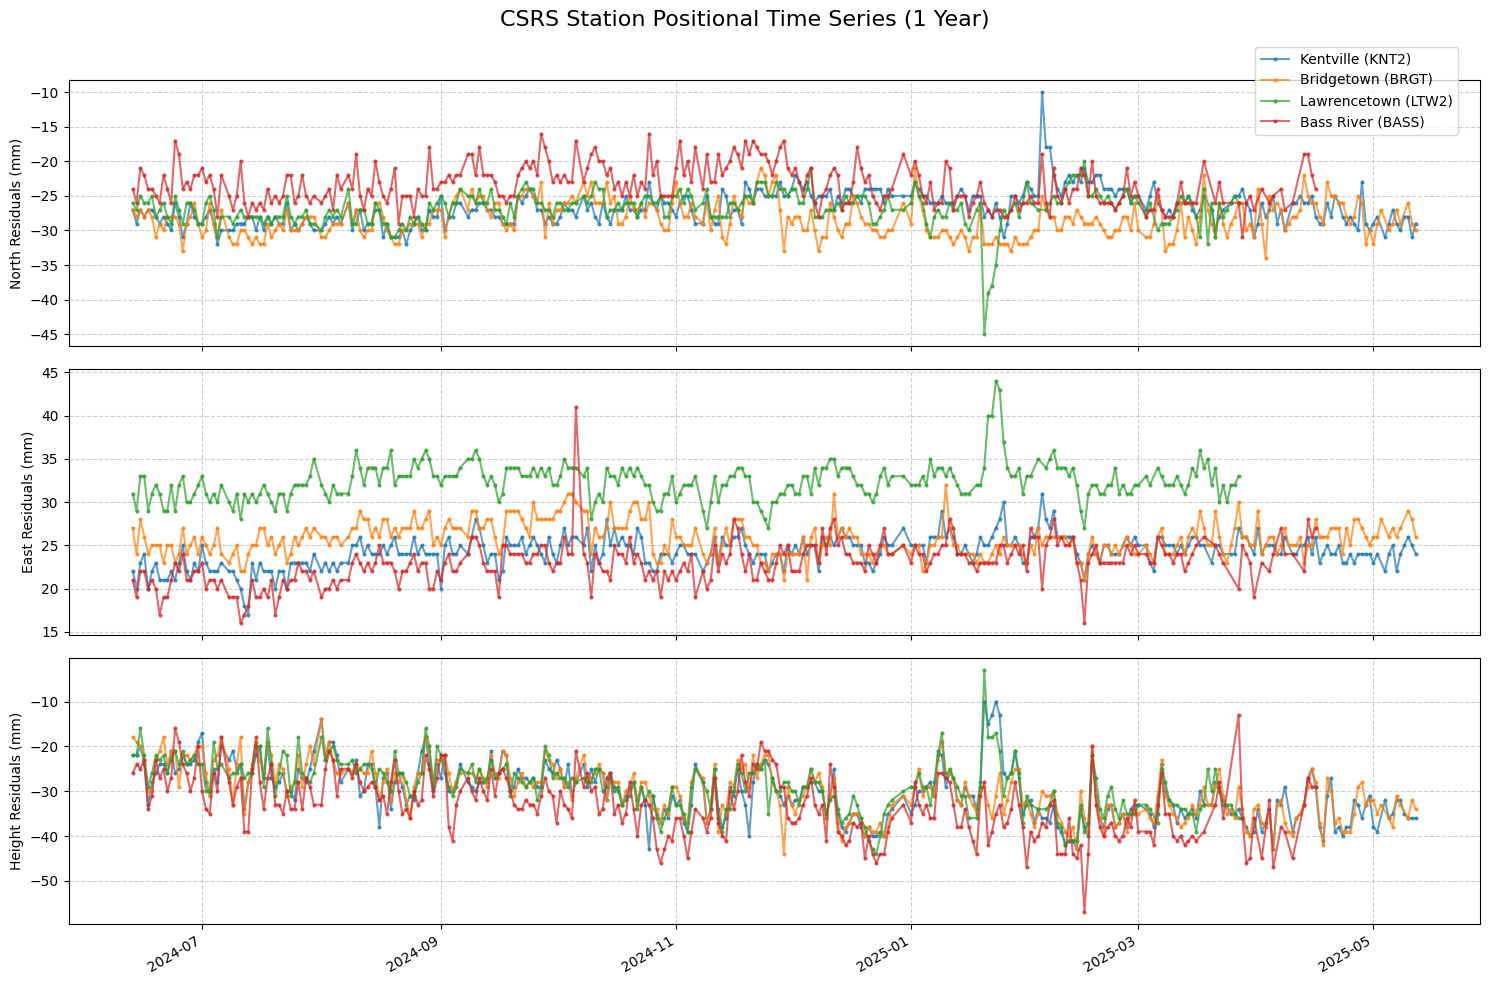

In [ ]:
import requests
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- CONFIGURATION ---
# We map a human-readable name to the official CSRS Monument ID.
STATIONS_TO_PLOT = {
    'Kentville (KNT2)': 'NS50025',
    'Bridgetown (BRGT)': 'NS50024',
    'Lawrencetown (LTW2)': 'NS50041',
    'Bass River (BASS)': 'NS50022' # Added Bass River from your example
}

def plot_station_timeseries(station_dict):
    """
    Fetches and plots a high-precision daily position time series for a
    set of geodetic stations to visualize their stability.
    This version correctly parses the CSRS API's dplh JSON structure.
    """
    print("--- Starting Station Stability Analysis (Corrected Parser) ---")

    # --- Setup Dates for API Call ---
    # We will plot data for the last 365 days.
    end_date = datetime.date.today()
    start_date = end_date - datetime.timedelta(days=365)

    # --- Setup the Plot ---
    fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    fig.suptitle('CSRS Station Positional Time Series (1 Year)', fontsize=16)

    # --- Loop Through Each Station and Plot its Data ---
    for station_name, monument_id in station_dict.items():
        print(f"\nFetching data for: {station_name} ({monument_id})...")

        # --- Construct API URL ---
        params = {
            'dataType': 'json',
            'start': start_date.isoformat(),
            'end': end_date.isoformat(),
            'station': monument_id,
            'solution': 's4pp_dcr_gnss_R2',
            'apply_velocity': 'false'
        }
        base_url = 'https://webapp.csrs-scrs.nrcan-rncan.gc.ca/CSRS/tools/dplh/timeseries'

        # --- Fetch Data ---
        try:
            response = requests.get(base_url, params=params, timeout=30)
            response.raise_for_status()
            data = response.json()
        except requests.exceptions.RequestException as e:
            print(f"  ERROR: Could not fetch data for {station_name}. Reason: {e}")
            continue

        # --- CORRECTED DATA PROCESSING ---
        # The API provides residuals directly in the 'dplh' key.
        if not data.get('dplh'):
             print(f"  INFO: No 'dplh' data returned for {station_name} in the given period.")
             continue

        try:
            # Extract dates and convert them to Python datetime objects
            epochs = [datetime.datetime.strptime(d['date'], '%Y-%m-%d').date() for d in data['dplh']]

            # Extract the N, E, U residuals (in meters) and convert to millimeters
            north_residuals_mm = [float(d['N']) * 1000 for d in data['dplh']]
            east_residuals_mm = [float(d['E']) * 1000 for d in data['dplh']]
            up_residuals_mm = [float(d['U']) * 1000 for d in data['dplh']]

            print(f"  SUCCESS: Fetched and processed {len(epochs)} data points.")
        except (KeyError, TypeError) as e:
            print(f"  ERROR: Could not parse the JSON data for {station_name}. It might have an unexpected format. Error: {e}")
            continue

        # --- Plotting ---
        axes[0].plot(epochs, north_residuals_mm, '.-', markersize=4, alpha=0.7, label=station_name)
        axes[1].plot(epochs, east_residuals_mm, '.-', markersize=4, alpha=0.7, label=station_name)
        axes[2].plot(epochs, up_residuals_mm, '.-', markersize=4, alpha=0.7, label=station_name)

    # --- Final Formatting ---
    axes[0].set_ylabel('North Residuals (mm)')
    axes[0].grid(True, linestyle='--', alpha=0.6)

    axes[1].set_ylabel('East Residuals (mm)')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    axes[2].set_ylabel('Height Residuals (mm)')
    axes[2].grid(True, linestyle='--', alpha=0.6)

    axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()

    handles, labels = axes[0].get_legend_handles_labels()
    # Check if there are any labels to prevent a UserWarning if no data was plotted
    if labels:
        fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.95))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    print("\n--- Plot generated. Displaying now. ---")
    plt.show()

# --- Run the script ---
if __name__ == '__main__':
    plot_station_timeseries(STATIONS_TO_PLOT)